In [41]:
from datascience import *
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline


In [42]:
def standard_units(x):
    """Converts an array x to standard units"""
    return (x - np.mean(x)) / np.std(x)

def correlation(t, x, y):
    x_su = standard_units(t.column(x))
    y_su = standard_units(t.column(y))
    return np.mean(x_su * y_su)


demographics = Table.read_table('district_demographics2016.csv')
demographics.show(5)




State,District,Median Income,Percent voting for Clinton,College%
Alabama,"Congressional District 1 (115th Congress), Alabama",47083,34.1,24
Alabama,"Congressional District 2 (115th Congress), Alabama",42035,33,21.8
Alabama,"Congressional District 3 (115th Congress), Alabama",46544,32.3,22.8
Alabama,"Congressional District 4 (115th Congress), Alabama",41110,17.4,17
Alabama,"Congressional District 5 (115th Congress), Alabama",51690,31.3,30.3


In [43]:
# Some functions for plotting. You don't have to understand how any
# of the functions in this cell work, since they use things we 
# haven't learned about in Data 8.

def resize_window(lim=3.5):
    plt.xlim(-lim, lim)
    plt.ylim(-lim, lim)
    
def draw_line(slope=0, intercept=0, x=make_array(-4, 4), color='r'):
    y = x*slope + intercept
    plt.plot(x, y, color=color)
    
def draw_vertical_line(x_position, color='black'):
    x = make_array(x_position, x_position)
    y = make_array(-4, 4)
    plt.plot(x, y, color=color)
    
def make_correlated_data(r):
    x = np.random.normal(0, 1, 1000)
    z = np.random.normal(0, 1, 1000)
    y = r*x + (np.sqrt(1-r**2))*z
    return x, y

def r_table(r):
    """
    Generate a table of 1000 x,y data points in standard units
    whose correlation is approximately equal to r
    """
    np.random.seed(8)
    x, y = make_correlated_data(r)
    return Table().with_columns('x', x, 'y', y)

In [44]:
def demographics_errors(slope, intercept):
    # Use four convenient points from the original data
    sample = [[14.7, 33995], [19.1, 61454], [50.7, 71183], [59.5, 105918]]
    demographics.scatter('College%', 'Median Income', alpha=0.5)
    xlims = make_array(5, 75)
    # Plot a line with the slope and intercept you specified:
    plt.plot(xlims, slope * xlims + intercept, lw=4)
    # Plot red lines from each of the four points to the line
    for x, y in sample:
        plt.plot([x, x], [y, slope * x + intercept], color='r', lw=4)


In [45]:
def show_demographics_rmse(slope, intercept):
    demographics_errors(slope, intercept)
    x = demographics.column('College%')
    y = demographics.column('Median Income')
    prediction = slope * x + intercept
    mse = np.mean((y - prediction) ** 2)
    print("Root mean squared error:", round(mse ** 0.5, 2))



In [46]:
def fitted_values(t, x, y):
    """Return an array of the regressions estimates at all the x values"""
    a = slope(t, x, y)
    b = intercept(t, x, y)
    return a*t.column(x) + b

In [47]:


def slope(t, x, y):
    return correlation(t, x, y) * (
        np.std(t.column(y)) / np.std(t.column(x))
    )
    
def intercept(t, x, y):
    return np.mean(t.column(y)) - slope(t, x, y) * np.mean(t.column(x))



In [48]:
example = r_table(0.5)
slope(example, "x", "y")

0.50226382816259152

In [49]:
mean_x = 70
sd_x = 10


mean_y = 50
sd_y = 12

r = 0.75

x = 60

x_su = (x - mean_x) / sd_x
y_pred_su = r * x_su

y_pred = (y_pred_su * sd_y + mean_y) 
y_pred

41.0

In [50]:


demographics = demographics.drop(
    'State', 'District', 'Percent voting for Clinton')
demographics.show(5)



Median Income,College%
47083,24
42035,21.8
46544,22.8
41110,17
51690,30.3


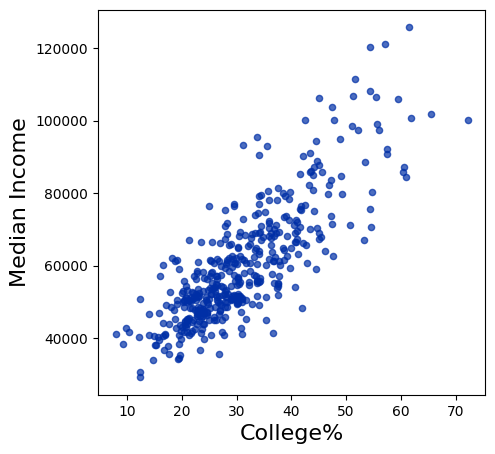

In [51]:
demographics.scatter('College%', 'Median Income')

In [52]:
correlation(demographics, 'College%', 'Median Income')

0.81846485171413352

In [53]:
regression_slope = slope(demographics, 'College%', 'Median Income')
regression_intercept = intercept(demographics, 'College%', 'Median Income')
regression_slope, regression_intercept


(1270.70168946388, 20802.577766677925)

In [54]:
predicted = fitted_values(demographics, 'College%', 'Median Income')

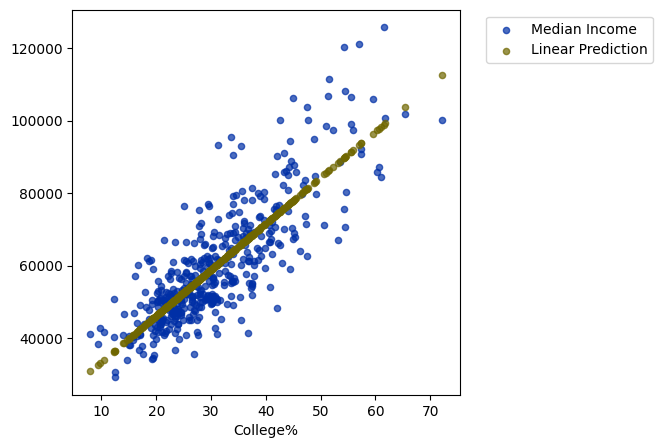

In [55]:
demographics = demographics.with_column(
    'Linear Prediction', predicted)
demographics.scatter('College%')

In [56]:


actual = demographics.column('Median Income')
errors = actual - predicted



In [57]:
demographics.with_column('Error', errors)

Median Income,College%,Linear Prediction,Error
47083,24,51299.4,-4216.42
42035,21.8,48503.9,-6468.87
46544,22.8,49774.6,-3230.58
41110,17,42404.5,-1294.51
51690,30.3,59304.8,-7614.84
61413,36.7,67437.3,-6024.33
34664,19.4,45454.2,-10790.2
76440,29.6,58415.3,18024.7
50537,24.5,51934.8,-1397.77
49072,34,64006.4,-14934.4


In [58]:
np.mean(errors)

6.3560089503211536e-13

In [59]:
np.mean(errors ** 2) ** 0.5

9398.5155885712811

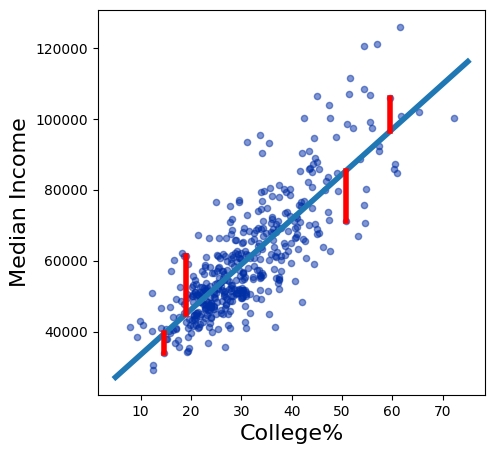

In [60]:
demographics_errors(regression_slope, regression_intercept)

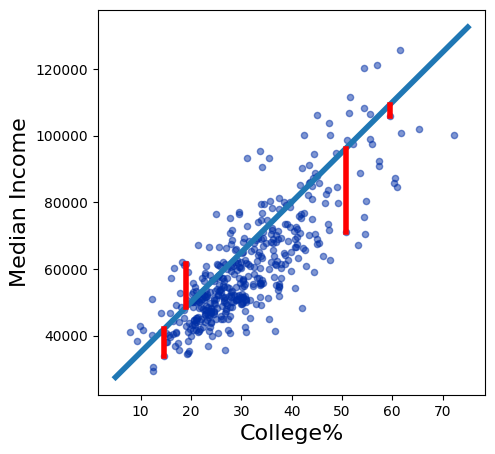

In [61]:
demographics_errors(1500, 20000)

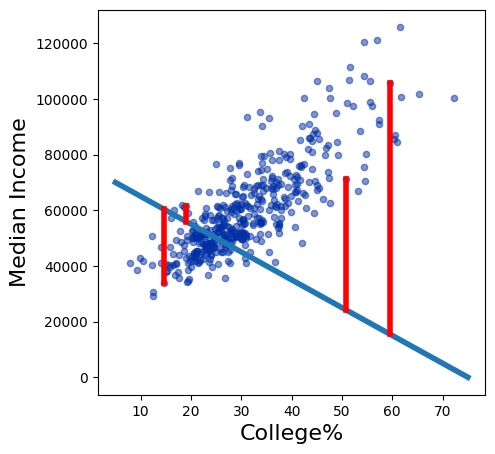

In [62]:
demographics_errors(-1000, 75000)